<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/C7_Regime_Characterization_%26_Log_Scale_Visibility_v0_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== 1. Fibonacci Recursive Attractor (C7 Example) ===

Golden ratio φ ≈ 1.6180339887
First 10 ratios and phases:
n= 2 | Ratio = 1.000000 | Phase = 0.00°
n= 3 | Ratio = 2.000000 | Phase = 0.00°
n= 4 | Ratio = 1.500000 | Phase = 180.00°
n= 5 | Ratio = 1.666667 | Phase = 240.00°
n= 6 | Ratio = 1.600000 | Phase = 216.00°
n= 7 | Ratio = 1.625000 | Phase = 225.00°
n= 8 | Ratio = 1.615385 | Phase = 221.54°
n= 9 | Ratio = 1.619048 | Phase = 222.86°
n=10 | Ratio = 1.617647 | Phase = 222.35°
n=11 | Ratio = 1.618182 | Phase = 222.55°

Log-scale error collapse (last 8 terms):
n=12 | log10(Error) = -4.25
n=13 | log10(Error) = -4.67
n=14 | log10(Error) = -5.08
n=15 | log10(Error) = -5.50
n=16 | log10(Error) = -5.92
n=17 | log10(Error) = -6.34
n=18 | log10(Error) = -6.76
n=19 | log10(Error) = -7.17


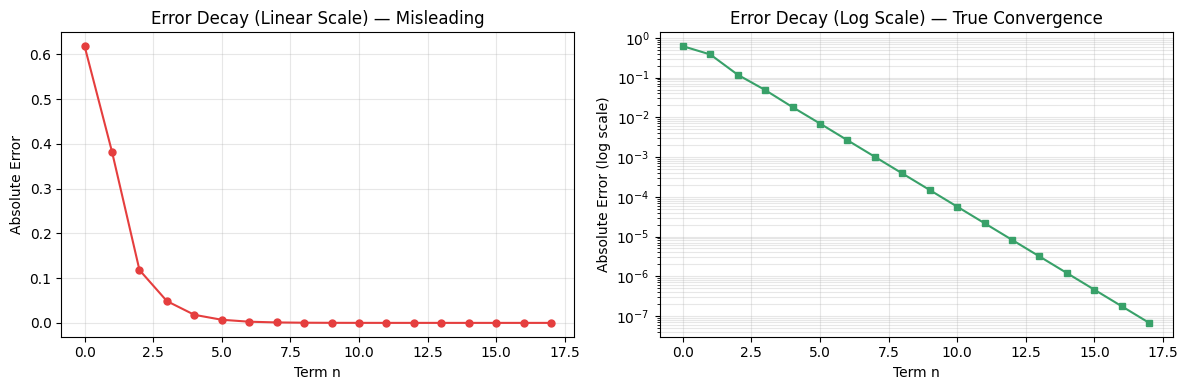


Note: Log scale is required to see the exponential collapse (C7 Section 2).

=== 2. Multi-Scale Log Visibility Demonstration ===



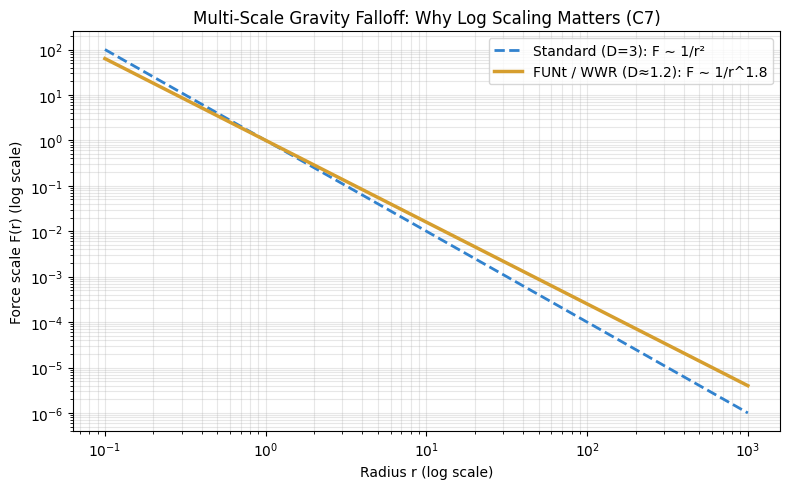

Observation: On log-log scales, the power-law difference between regimes becomes clear.
Linear scales would hide this distinction across decades of radius.

=== 3. Minimal Multi-Regime Ledger (C7) ===

Minimal regime ledger (matches C7 example):
  1: Regime Start | Regime_A   | R=  0- 47 | growth_limited
  2: Crossing     | A → B      | R= 48- 48 | —
  3: Regime Start | Regime_B   | R= 48-112 | transitional
  4: Crossing     | B → C      | R=113-113 | —
  5: Regime Start | Regime_C   | R=113-200 | stable

This ledger structure supports continuity across multiple regime crossings (C7 Section 3).

C7 Companion Notebook Complete

Key C7 principles demonstrated:
1. Recursive attractor convergence (Fibonacci → φ phase attractor)
2. Log-scale visibility is required to observe true error collapse
3. Multi-scale behavior (quark to nova) needs log scaling to characterize properly
4. Simple, traceable multi-regime ledger for continuity

This notebook is designed to be pasted into larger FUNt/WWR

In [1]:
# ============================================================
# C7 Companion Notebook — Regime Characterization & Log-Scale Visibility
# Matches C7 Draft v0.4 (Section 2 emphasis)
# Author: Michael K. Nowlin
# Purpose: Demonstrate multi-scale regime behavior + recursive attractor convergence
#          with proper log-scale visualization (as required by C7)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# -----------------------------
# 1. Fibonacci Attractor Example (from C7)
# -----------------------------
print("=== 1. Fibonacci Recursive Attractor (C7 Example) ===\n")

phi = (1 + np.sqrt(5)) / 2
print(f"Golden ratio φ ≈ {phi:.10f}")

def fibonacci_ratios(n_terms=20):
    """Generate Fibonacci ratios and phase angles (C7 style)."""
    a, b = 1, 1
    ratios = []
    phases = []
    for _ in range(n_terms):
        ratio = b / a
        ratios.append(ratio)
        # Phase projection: 360° * ratio mod 360°
        phase = (360 * ratio) % 360
        phases.append(phase)
        a, b = b, a + b
    return np.array(ratios), np.array(phases)

ratios, phases = fibonacci_ratios(18)

print("First 10 ratios and phases:")
for i in range(10):
    print(f"n={i+2:2d} | Ratio = {ratios[i]:.6f} | Phase = {phases[i]:.2f}°")

# Log-scale error tracking (critical per C7 Section 2)
errors = np.abs(ratios - phi)
print("\nLog-scale error collapse (last 8 terms):")
for i in range(-8, 0):
    print(f"n={i+20:2d} | log10(Error) = {np.log10(errors[i]):.2f}")

# Visualization - Linear vs Log error (side by side)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Left: Linear scale (hides the collapse)
axs[0].plot(errors, 'o-', color='#e53e3e', markersize=5)
axs[0].set_title("Error Decay (Linear Scale) — Misleading")
axs[0].set_xlabel("Term n")
axs[0].set_ylabel("Absolute Error")
axs[0].grid(True, alpha=0.3)

# Right: Log scale (reveals true exponential convergence)
axs[1].semilogy(errors, 's-', color='#38a169', markersize=5)
axs[1].set_title("Error Decay (Log Scale) — True Convergence")
axs[1].set_xlabel("Term n")
axs[1].set_ylabel("Absolute Error (log scale)")
axs[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: Log scale is required to see the exponential collapse (C7 Section 2).")

# -----------------------------
# 2. Multi-Scale Regime Behavior (C7 Section 2)
# -----------------------------
print("\n=== 2. Multi-Scale Log Visibility Demonstration ===\n")

# Toy model: Gravity falloff — Standard (D=3) vs FUNt (D≈1.20)
r = np.logspace(-1, 3, 400)   # radius from 0.1 to 1000 (multi-scale)

# Standard Newtonian / ΛCDM gravity
F_standard = 1.0 / r**2

# FUNt / WWR gravity with D ≈ 1.20
D_funt = 1.20
F_funt = 1.0 / r**(3.0 - D_funt)   # exponent ≈ 1.8

plt.figure(figsize=(8, 5))
plt.loglog(r, F_standard, '--', lw=2, label="Standard (D=3): F ∼ 1/r²", color='#3182ce')
plt.loglog(r, F_funt,      lw=2.5, label=f"FUNt / WWR (D≈{D_funt}): F ∼ 1/r^{3-D_funt:.1f}", color='#d69e2e')
plt.xlabel("Radius r (log scale)")
plt.ylabel("Force scale F(r) (log scale)")
plt.title("Multi-Scale Gravity Falloff: Why Log Scaling Matters (C7)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation: On log-log scales, the power-law difference between regimes becomes clear.")
print("Linear scales would hide this distinction across decades of radius.")

# -----------------------------
# 3. Simple Regime Ledger Example (C7 Section 3)
# -----------------------------
print("\n=== 3. Minimal Multi-Regime Ledger (C7) ===\n")

ledger = [
    {"entry": 1, "event": "Regime Start", "label": "Regime_A", "r_start": 0,   "r_end": 47,  "behavior": "growth_limited"},
    {"entry": 2, "event": "Crossing",     "label": "A → B",    "r_start": 48,  "r_end": 48,  "behavior": "—"},
    {"entry": 3, "event": "Regime Start", "label": "Regime_B", "r_start": 48,  "r_end": 112, "behavior": "transitional"},
    {"entry": 4, "event": "Crossing",     "label": "B → C",    "r_start": 113, "r_end": 113, "behavior": "—"},
    {"entry": 5, "event": "Regime Start", "label": "Regime_C", "r_start": 113, "r_end": 200, "behavior": "stable"},
]

print("Minimal regime ledger (matches C7 example):")
for row in ledger:
    print(f"  {row['entry']}: {row['event']:12s} | {row['label']:10s} | R={row['r_start']:3d}-{row['r_end']:3d} | {row['behavior']}")

print("\nThis ledger structure supports continuity across multiple regime crossings (C7 Section 3).")

# -----------------------------
# Summary
# -----------------------------
print("\n" + "="*60)
print("C7 Companion Notebook Complete")
print("="*60)
print("""
Key C7 principles demonstrated:
1. Recursive attractor convergence (Fibonacci → φ phase attractor)
2. Log-scale visibility is required to observe true error collapse
3. Multi-scale behavior (quark to nova) needs log scaling to characterize properly
4. Simple, traceable multi-regime ledger for continuity

This notebook is designed to be pasted into larger FUNt/WWR workflows.
""")